This file is dedicated to testing different features in the Logistic Regression models, in order to find the best selection of features for this particular type of model. 

TODO

Introduce step by step the remaining features, that either had missing values or were categorical. 

TARGET_B                      0
MONTHS_SINCE_ORIGIN           0
IN_HOUSE                      0
MOR_HIT_RATE                  0
MEDIAN_HOME_VALUE             0
MEDIAN_HOUSEHOLD_INCOME       0
PCT_OWNER_OCCUPIED            0
PER_CAPITA_INCOME             0
PCT_ATTRIBUTE1                0
PCT_ATTRIBUTE2                0
PCT_ATTRIBUTE3                0
PCT_ATTRIBUTE4                0
PEP_STAR                      0
RECENT_STAR_STATUS            0
FREQUENCY_STATUS_97NK         0
RECENT_RESPONSE_PROP          0
RECENT_AVG_GIFT_AMT           0
RECENT_CARD_RESPONSE_PROP     0
RECENT_AVG_CARD_GIFT_AMT      0
RECENT_RESPONSE_COUNT         0
RECENT_CARD_RESPONSE_COUNT    0
LIFETIME_CARD_PROM            0
LIFETIME_PROM                 0
LIFETIME_GIFT_AMOUNT          0
LIFETIME_GIFT_COUNT           0
LIFETIME_AVG_GIFT_AMT         0
LIFETIME_GIFT_RANGE           0
LIFETIME_MAX_GIFT_AMT         0
LIFETIME_MIN_GIFT_AMT         0
LAST_GIFT_AMT                 0
CARD_PROM_12                  0
NUMBER_P

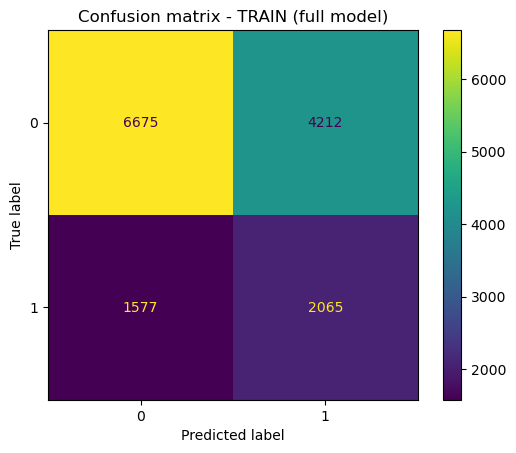

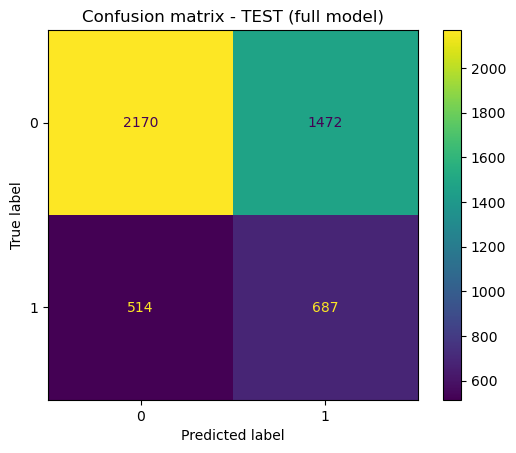


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.81      0.61      0.70     10887
           1       0.33      0.57      0.42      3642

    accuracy                           0.60     14529
   macro avg       0.57      0.59      0.56     14529
weighted avg       0.69      0.60      0.63     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      3642
           1       0.32      0.57      0.41      1201

    accuracy                           0.59      4843
   macro avg       0.56      0.58      0.55      4843
weighted avg       0.69      0.59      0.62      4843



In [6]:
### testing all complete numerical features. I tmakes sense, since this model is for numerical variables. 
### Results: Increasing the number of features improves the results very slightly, when in comparison with the 18 used for the study of hyperparameters. 
### In an attempt to reduce noise, the next step will be the removal on the features with coeficients close to zero and see how that works out. 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]

cat_features = [
]

C = 100
penalty = 'l2' # or l1
solver = 'liblinear'


# Default parameters are:
# C = 1
# pnalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.

label_balance = 'balanced'
# you can make your balance between the two labels by adding a new label_weight as a dictionary:
# label_weight = {0: 1.0, 1: 2.0}



# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B


# check missing values
print(df_B.isna().sum())

# 3) One-hot encode only the categorical features
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True)

# 4) Final X and y
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']




X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Fit logistic regression
logreg_full = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000000, class_weight=label_balance)
logreg_full.fit(X_B_train, y_B_train)


### Confusion matrices. Again the results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_B_train)
y_B_test_pred  = logreg_full.predict(X_B_test)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()


### Evaluation metrics

from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train, y_B_train_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))

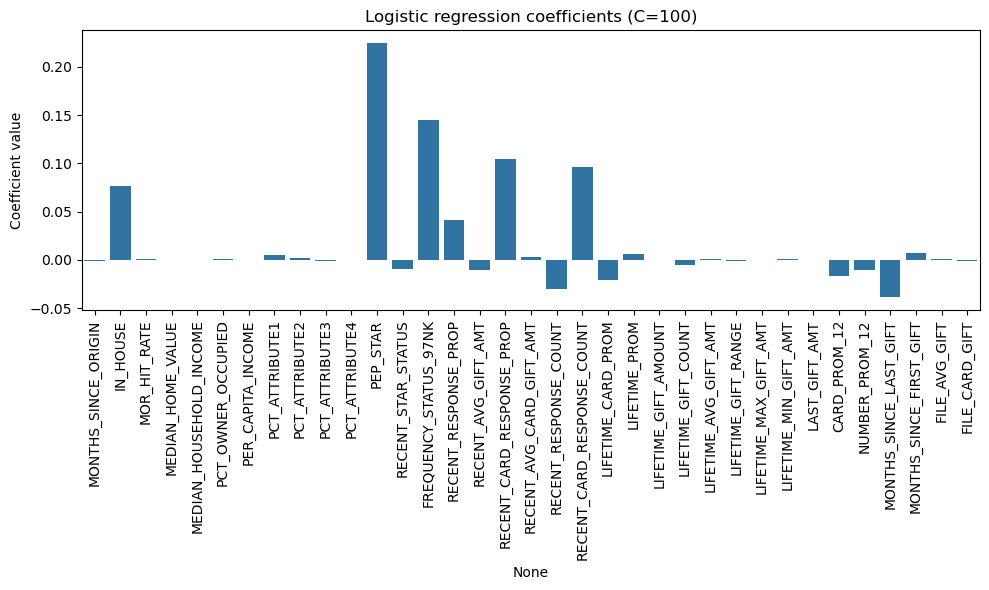

                       feature  coefficient
11                    PEP_STAR     0.224674
13       FREQUENCY_STATUS_97NK     0.144605
16   RECENT_CARD_RESPONSE_PROP     0.104065
19  RECENT_CARD_RESPONSE_COUNT     0.096326
1                     IN_HOUSE     0.076229
14        RECENT_RESPONSE_PROP     0.041609
31      MONTHS_SINCE_LAST_GIFT    -0.038395
18       RECENT_RESPONSE_COUNT    -0.029786
20          LIFETIME_CARD_PROM    -0.020705
29                CARD_PROM_12    -0.016512
30              NUMBER_PROM_12    -0.010511
15         RECENT_AVG_GIFT_AMT    -0.010336
12          RECENT_STAR_STATUS    -0.009142
32     MONTHS_SINCE_FIRST_GIFT     0.006762
21               LIFETIME_PROM     0.006078
23         LIFETIME_GIFT_COUNT    -0.005312
7               PCT_ATTRIBUTE1     0.004975
17    RECENT_AVG_CARD_GIFT_AMT     0.003271
8               PCT_ATTRIBUTE2     0.002037
0          MONTHS_SINCE_ORIGIN    -0.001620
2                 MOR_HIT_RATE     0.001152
24       LIFETIME_AVG_GIFT_AMT  

In [8]:
# Presents the coefficients of the model for each feature.  

import seaborn as sns
import pandas as pd


plt.figure(figsize=(10, 6))
sns.barplot(x=X_B_train.columns, y=logreg_full.coef_.flatten())
plt.xticks(rotation=90)
plt.ylabel("Coefficient value")
plt.title("Logistic regression coefficients (C=100)")
plt.tight_layout()
plt.show()



coef_table = pd.DataFrame({
    "feature": X_B_train.columns,
    "coefficient": logreg_full.coef_.flatten()
})

# Optional: sort by absolute value of coefficient
coef_table["abs_coeff"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coeff", ascending=False).drop(columns="abs_coeff")

print(coef_table)

TARGET_B                      0
IN_HOUSE                      0
PEP_STAR                      0
FREQUENCY_STATUS_97NK         0
RECENT_RESPONSE_PROP          0
RECENT_AVG_GIFT_AMT           0
RECENT_CARD_RESPONSE_PROP     0
RECENT_RESPONSE_COUNT         0
RECENT_CARD_RESPONSE_COUNT    0
LIFETIME_CARD_PROM            0
CARD_PROM_12                  0
MONTHS_SINCE_LAST_GIFT        0
dtype: int64


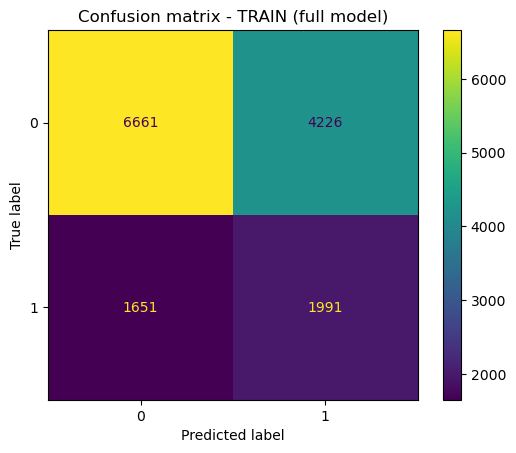

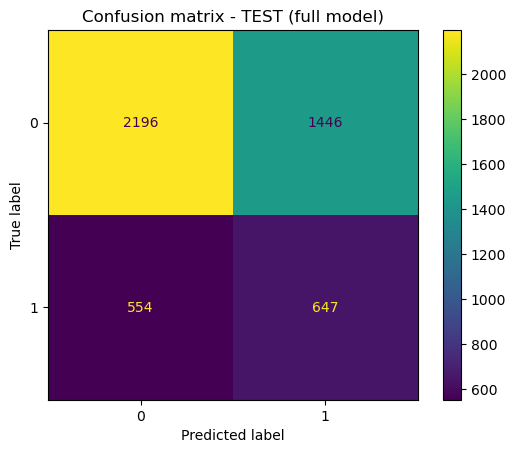


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.80      0.61      0.69     10887
           1       0.32      0.55      0.40      3642

    accuracy                           0.60     14529
   macro avg       0.56      0.58      0.55     14529
weighted avg       0.68      0.60      0.62     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.80      0.60      0.69      3642
           1       0.31      0.54      0.39      1201

    accuracy                           0.59      4843
   macro avg       0.55      0.57      0.54      4843
weighted avg       0.68      0.59      0.61      4843



In [10]:
### In here I kept only the features with the highest coeficients, non standartized. The results decreased slightly. Not a good approach. 

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = [
    "IN_HOUSE",#
    "PEP_STAR",#
    "FREQUENCY_STATUS_97NK",#
    "RECENT_RESPONSE_PROP",#
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",#
    "RECENT_RESPONSE_COUNT",#
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",#
    "CARD_PROM_12",#
    "MONTHS_SINCE_LAST_GIFT",#
]
cat_features = [
]

C = 100
penalty = 'l2' # or l1
solver = 'liblinear'


# Default parameters are:
# C = 1
# pnalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.

label_balance = 'balanced'
# you can make your balance between the two labels by adding a new label_weight as a dictionary:
# label_weight = {0: 1.0, 1: 2.0}



# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B


# check missing values
print(df_B.isna().sum())

# 3) One-hot encode only the categorical features
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True)

# 4) Final X and y
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']




X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Fit logistic regression
logreg_full = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000000, class_weight=label_balance)
logreg_full.fit(X_B_train, y_B_train)


### Confusion matrices. Again the results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_B_train)
y_B_test_pred  = logreg_full.predict(X_B_test)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()


### Evaluation metrics

from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train, y_B_train_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))

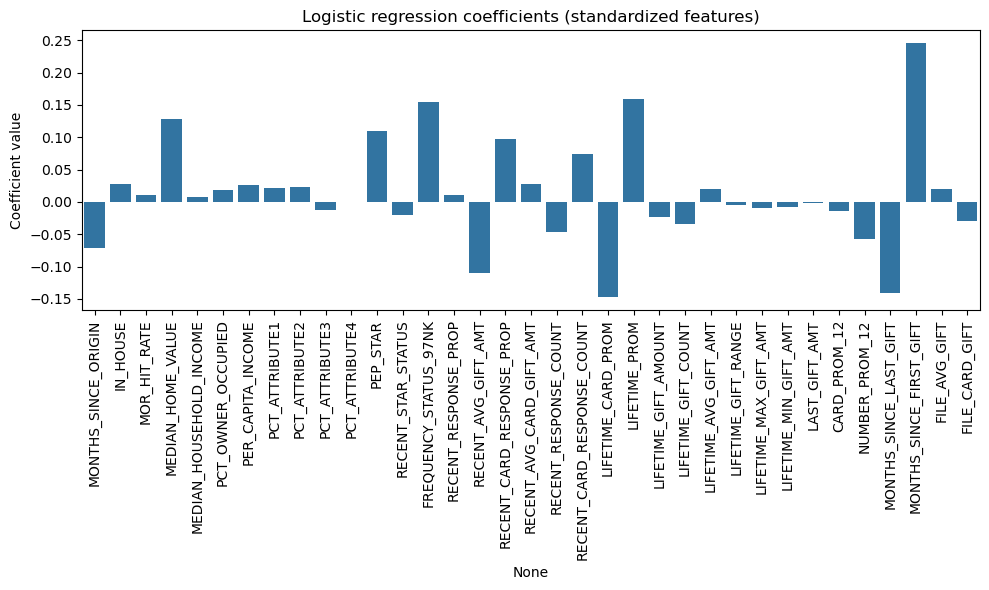

                       feature  coefficient
32     MONTHS_SINCE_FIRST_GIFT     0.245644
21               LIFETIME_PROM     0.159613
13       FREQUENCY_STATUS_97NK     0.154866
20          LIFETIME_CARD_PROM    -0.146997
31      MONTHS_SINCE_LAST_GIFT    -0.141401
3            MEDIAN_HOME_VALUE     0.127934
11                    PEP_STAR     0.109523
15         RECENT_AVG_GIFT_AMT    -0.109340
16   RECENT_CARD_RESPONSE_PROP     0.096524
19  RECENT_CARD_RESPONSE_COUNT     0.074121
0          MONTHS_SINCE_ORIGIN    -0.071653
30              NUMBER_PROM_12    -0.056900
18       RECENT_RESPONSE_COUNT    -0.046594
23         LIFETIME_GIFT_COUNT    -0.033544
34              FILE_CARD_GIFT    -0.029393
17    RECENT_AVG_CARD_GIFT_AMT     0.027698
1                     IN_HOUSE     0.027436
6            PER_CAPITA_INCOME     0.026124
22        LIFETIME_GIFT_AMOUNT    -0.023804
8               PCT_ATTRIBUTE2     0.023676
7               PCT_ATTRIBUTE1     0.021460
33               FILE_AVG_GIFT  

In [3]:
### Checking which features have a hight coeficient wshen standartized. 

import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Standardize features (fit on train, transform both)
scaler = StandardScaler()
X_B_train_std = scaler.fit_transform(X_B_train)
X_B_test_std  = scaler.transform(X_B_test)

# Refit logistic regression on standardized data
logreg_full_std = LogisticRegression(
    C=C,
    penalty=penalty,
    solver=solver,
    max_iter=100000000,
    class_weight=label_balance
)
logreg_full_std.fit(X_B_train_std, y_B_train)

# Plot coefficients (standardized)
plt.figure(figsize=(10, 6))
sns.barplot(x=X_B_train.columns, y=logreg_full_std.coef_.flatten())
plt.xticks(rotation=90)
plt.ylabel("Coefficient value")
plt.title("Logistic regression coefficients (standardized features)")
plt.tight_layout()
plt.show()

# Table of coefficients, sorted by |coef|
coef_table = pd.DataFrame({
    "feature": X_B_train.columns,
    "coefficient": logreg_full_std.coef_.flatten()
})

coef_table["abs_coeff"] = coef_table["coefficient"].abs()
coef_table = coef_table.sort_values("abs_coeff", ascending=False).drop(columns="abs_coeff")

print(coef_table)

TARGET_B                      0
MONTHS_SINCE_ORIGIN           0
MEDIAN_HOME_VALUE             0
MEDIAN_HOUSEHOLD_INCOME       0
PEP_STAR                      0
FREQUENCY_STATUS_97NK         0
RECENT_AVG_GIFT_AMT           0
RECENT_CARD_RESPONSE_PROP     0
RECENT_AVG_CARD_GIFT_AMT      0
RECENT_RESPONSE_COUNT         0
RECENT_CARD_RESPONSE_COUNT    0
LIFETIME_CARD_PROM            0
LIFETIME_PROM                 0
NUMBER_PROM_12                0
MONTHS_SINCE_LAST_GIFT        0
MONTHS_SINCE_FIRST_GIFT       0
dtype: int64


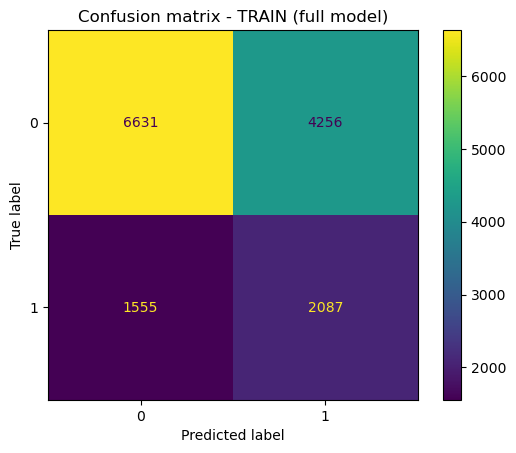

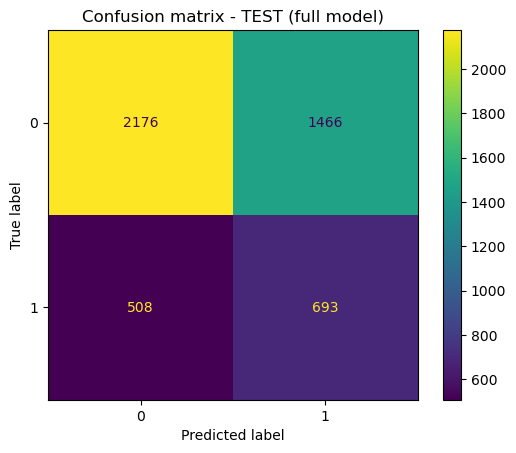


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.81      0.61      0.70     10887
           1       0.33      0.57      0.42      3642

    accuracy                           0.60     14529
   macro avg       0.57      0.59      0.56     14529
weighted avg       0.69      0.60      0.63     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      3642
           1       0.32      0.58      0.41      1201

    accuracy                           0.59      4843
   macro avg       0.57      0.59      0.55      4843
weighted avg       0.69      0.59      0.62      4843



In [4]:
### In here I kept only the features with the highest coeficients after standartized. It improved the results slightly in the matrices. 

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = [
    "MONTHS_SINCE_ORIGIN",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PEP_STAR",
    "FREQUENCY_STATUS_97NK",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
]

cat_features = [
]

C = 100
penalty = 'l2' # or l1
solver = 'liblinear'


# Default parameters are:
# C = 1
# pnalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.

label_balance = 'balanced'
# you can make your balance between the two labels by adding a new label_weight as a dictionary:
# label_weight = {0: 1.0, 1: 2.0}



# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B


# check missing values
print(df_B.isna().sum())

# 3) One-hot encode only the categorical features
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True)

# 4) Final X and y
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']




X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Fit logistic regression
logreg_full = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000000, class_weight=label_balance)
logreg_full.fit(X_B_train, y_B_train)


### Confusion matrices. Again the results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_B_train)
y_B_test_pred  = logreg_full.predict(X_B_test)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()


### Evaluation metrics

from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train, y_B_train_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))

In [ ]:
### Brute force to find he best possible combination of features. 

from itertools import combinations
from sklearn.metrics import f1_score
import numpy as np


MAX_FEATURES = 10  # change if you want to try larger subsets

all_cols = list(X_B_train.columns)

results = []

for k in range(1, MAX_FEATURES + 1):
    for subset in combinations(all_cols, k):
        cols = list(subset)

        Xtr = X_B_train[cols]
        Xte = X_B_test[cols]

        clf = LogisticRegression(
            C=C,
            penalty=penalty,
            solver=solver,
            max_iter=100,
            class_weight=label_balance
        )
        clf.fit(Xtr, y_B_train)

        y_pred = clf.predict(Xte)

        f1_1 = f1_score(y_B_test, y_pred, pos_label=1)
        f1_0 = f1_score(y_B_test, y_pred, pos_label=0)

        results.append({
            "features": cols,
            "num_features": k,
            "f1_class1": f1_1,
            "f1_class0": f1_0
        })

# Sort: first by F1 for donors (desc), then by F1 for non-donors (desc)
results_sorted = sorted(
    results,
    key=lambda d: (-d["f1_class1"], -d["f1_class0"])
)

# Take the top 10
top_10 = results_sorted[:10]

# Put in a DataFrame for easier viewing
top_10_df = pd.DataFrame(top_10)
print(top_10_df)


The test using exclusivly numerical features are over. From now on we will use the 